# Machine Learning #02 — Classification & Regression with PyTorch 🔥

Last time we trained a **binary classifier**. Today we take two steps further and show that
**classification and regression are almost the same thing** in a neural network.

We will build **two networks** with PyTorch:

1. 🏷️ **Classification** — recognise hand-written digits (**MNIST**, 10 classes).
2. 📈 **Regression** — predict a car's fuel economy (**Auto MPG**, a continuous number).



## 🎯 The big idea: what changes between the two tasks?

Everything you learned in lesson #1 stays. Only the **"head"** of the model and the training
targets change. Keep this table in mind for the whole lesson — we will refer back to it:

| | 🏷️ **Classification** (MNIST) | 📈 **Regression** (Auto MPG) |
|---|---|---|
| **Question** | *Which class?* (a category) | *How much?* (a number) |
| **Output neurons** | one per class (**10**) | **1** |
| **Output activation** | none in model → `softmax` at eval | **none / linear** |
| **Loss function** | `nn.CrossEntropyLoss` | `nn.MSELoss` |
| **Metric** | accuracy | MAE, RMSE, $R^2$ |
| **Target dtype** | `int64` (class index) | `float32` (real value) |

Everything else — the hidden layers, `ReLU`, `Dropout`, the optimizer, the training loop —
is **identical**.

## Imports & setup ⚙️

Remember to switch the Colab runtime to **GPU** (*Runtime → Change runtime type → T4 GPU*).

In [2]:
!pip install torchinfo

In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import torchinfo
from torchvision import datasets   # only used to download MNIST as plain tensors

import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score)

sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch version:", torch.__version__)
print("device:", device)

torch version: 2.11.0+cu128
device: cuda


### 🟰 One training loop for both tasks

In lesson #1 the dataset was tiny, so we pushed **all** the data through the network at once
(*full-batch*). MNIST has tens of thousands of images — too many for one step — so we **upgrade**
the loop to **mini-batches** using a `DataLoader`.

The structure is exactly the one you already know (`model.train()` → forward → `backward()` →
`optimizer.step()`, then `model.eval()` for validation). The only new thing is the **inner loop**
over batches. We write it **once** and reuse it for *both* the classifier and the regressor. 🔁

In [5]:
def train_model(model, train_loader, val_loader, criterion, optimizer, n_epochs=15):
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(n_epochs):
        # ---- training phase ----
        model.train()                     # enable dropout
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()         # reset gradients
            loss = criterion(model(xb), yb)
            loss.backward()               # autograd computes gradients
            optimizer.step()              # update the weights
            running += loss.item() * xb.size(0)
        train_loss = running / len(train_loader.dataset)

        # ---- validation phase ----
        model.eval()                      # disable dropout
        running = 0.0
        with torch.no_grad():             # no gradients needed here
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                running += criterion(model(xb), yb).item() * xb.size(0)
        val_loss = running / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        if (epoch + 1) % max(1, n_epochs // 10) == 0:
            print(f"epoch {epoch+1:>3}/{n_epochs}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

    return history

# 🏷️ Part 1 — Classification: MNIST digits

**MNIST** is the classic "hello world" of deep learning: 70,000 grayscale images of hand-written
digits (28×28 pixels), each labelled **0–9**.

### Why a plain (fully-connected) network and not a CNN? 🤔
Convolutional networks (CNNs) are the *right* tool for images and we cover them **next lesson**.
Today we deliberately use a simple **MLP** (Multi-Layer Perceptron): we **flatten** each 28×28
image into a vector of **784 numbers** and treat those as ordinary features — exactly like the
sloth measurements last week, just more of them.

In [6]:
  # torchvision gives us MNIST as ready-made tensors
  train_full = datasets.MNIST(root="./data", train=True,  download=True)
  test_ds    = datasets.MNIST(root="./data", train=False, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 15.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 460kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.63MB/s]


In [ ]:
train_full.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [7]:
# .data -> uint8 pixels in [0, 255], shape [N, 28, 28];  .targets -> class index 0..9
X_all = train_full.data.float() / 255.0     # normalise pixels to [0, 1]  (same idea as scaling features)
y_all = train_full.targets                  # already int64 -> perfect for CrossEntropyLoss

X_test_full = test_ds.data.float() / 255.0
y_test_full = test_ds.targets

print("images:", X_all.shape, "| labels:", y_all.shape, "| pixel range:", X_all.min().item(), "-", X_all.max().item())

images: torch.Size([60000, 28, 28]) | labels: torch.Size([60000]) | pixel range: 0.0 - 1.0


In [8]:
X_all.shape, y_all.shape

(torch.Size([60000, 28, 28]), torch.Size([60000]))

In [9]:
X_test_full.shape, y_test_full.shape

(torch.Size([10000, 28, 28]), torch.Size([10000]))

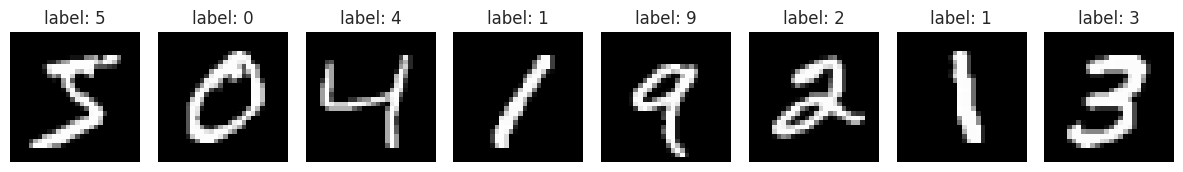

In [10]:
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, img, label in zip(axes, X_all[:8], y_all[:8]):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"label: {label.item()}")
    ax.axis("off")
plt.tight_layout()
plt.show()

### Train / validation / test split

To keep the lab fast we work with a **subset** of the training data. Everything below works
identically on the full 60,000 images — it would just take longer to train. ⏱️

In [11]:
X_train, y_train = X_all[:10000],       y_all[:10000]
X_val,   y_val   = X_all[10000:12000],  y_all[10000:12000]
X_test,  y_test  = X_test_full,         y_test_full          # full 10k test set

# Wrap tensors into DataLoaders (mini-batches)
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=256)

print("train:", X_train.shape[0], "| val:", X_val.shape[0], "| test:", X_test.shape[0])

train: 10000 | val: 2000 | test: 10000


### 🌳 Baseline first: is a neural network even worth it?

Before deep learning, let's see how a **plain Decision Tree** does. A baseline tells us whether
the extra complexity of a neural network actually pays off.

In [12]:
# Decision trees need a flat feature vector -> reshape 28x28 into 784
tree = DecisionTreeClassifier(random_state=SEED)
tree.fit(X_train.reshape(-1, 28*28).numpy(), y_train.numpy())
tree_acc = accuracy_score(y_test.numpy(), tree.predict(X_test.reshape(-1, 28*28).numpy()))
print(f"Decision Tree test accuracy: {tree_acc:.3f}")

Decision Tree test accuracy: 0.809


### 🧠 Build the first architecture (`nn.Module`)

As requested, we use the **`nn.Module` class style** (the flexible, "grown-up" way to define
networks). Notice the ingredients you asked to keep:

- **multiple hidden layers** (784 → 256 → 128 → 10),
- **`ReLU`** activations,
- **`Dropout`** for regularisation (randomly "switches off" neurons during training).

> 💡 The output layer has **10 neurons** (one per digit) and **no softmax inside the model**.
> `nn.CrossEntropyLoss` expects raw **logits** and applies the softmax internally — cleaner and
> numerically more stable.

In [13]:
class MnistMLPFirst(nn.Module):
    def __init__(self, n_classes=10, p_drop=0.2):
        super().__init__()                       # required first line
        self.flatten = nn.Flatten()              # [B, 28, 28] -> [B, 784]
        self.fc1     = nn.Linear(28*28, 256)     # hidden layer 1
        self.fc2     = nn.Linear(256, 128)       # hidden layer 2
        self.out     = nn.Linear(128, n_classes) # 10 output neurons (logits)
        self.dropout = nn.Dropout(p_drop)

    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.out(x)                          # raw logits, NO softmax here
        return x

model_01 = MnistMLPFirst().to(device)
torchinfo.summary(model_01, input_size=(1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
MnistMLPFirst                            [1, 10]                   --
├─Flatten: 1-1                           [1, 784]                  --
├─Linear: 1-2                            [1, 256]                  200,960
├─Dropout: 1-3                           [1, 256]                  --
├─Linear: 1-4                            [1, 128]                  32,896
├─Dropout: 1-5                           [1, 128]                  --
├─Linear: 1-6                            [1, 10]                   1,290
Total params: 235,146
Trainable params: 235,146
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.24
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.94
Estimated Total Size (MB): 0.95

#### ⚖️ Loss, optimizer & training

The **optimizer** (`Adam`) and the **training loop** are the same as always. Only the **loss**
is task-specific: `CrossEntropyLoss` for classification.

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_01.parameters(), lr=1e-3)

history = train_model(model_01, train_loader, val_loader, criterion, optimizer, n_epochs=15)

epoch   1/15  train_loss=0.7450  val_loss=0.3406
epoch   2/15  train_loss=0.3066  val_loss=0.2575
epoch   3/15  train_loss=0.2219  val_loss=0.2280
epoch   4/15  train_loss=0.1740  val_loss=0.1801
epoch   5/15  train_loss=0.1407  val_loss=0.1698
epoch   6/15  train_loss=0.1136  val_loss=0.1529
epoch   7/15  train_loss=0.0949  val_loss=0.1456
epoch   8/15  train_loss=0.0814  val_loss=0.1488
epoch   9/15  train_loss=0.0710  val_loss=0.1430
epoch  10/15  train_loss=0.0642  val_loss=0.1431
epoch  11/15  train_loss=0.0494  val_loss=0.1349
epoch  12/15  train_loss=0.0397  val_loss=0.1515
epoch  13/15  train_loss=0.0372  val_loss=0.1409
epoch  14/15  train_loss=0.0281  val_loss=0.1517
epoch  15/15  train_loss=0.0282  val_loss=0.1582


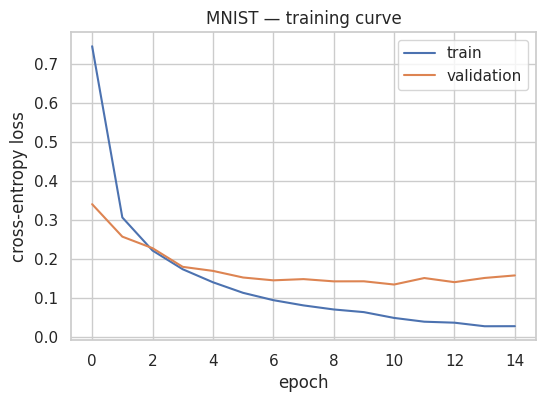

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"],   label="validation")
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("MNIST — training curve")
plt.legend()
plt.show()

#### 📊 Evaluation

To turn logits into a predicted class we apply **`softmax`** (→ probabilities) and take the
**`argmax`** (→ the most likely digit).

In [17]:
model_01.eval()
with torch.no_grad():
    logits = model_01(X_test.to(device))
    probs  = torch.softmax(logits, dim=1)   # logits -> probabilities that sum to 1
    preds  = probs.argmax(dim=1).cpu()      # pick the most likely class

In [18]:
print(probs[0])

tensor([2.5581e-10, 2.1742e-10, 6.7404e-07, 1.1514e-06, 8.8150e-13, 3.4627e-13,
        4.8317e-15, 1.0000e+00, 1.1022e-10, 1.6072e-08], device='cuda:0')


In [19]:
print(preds[0])

tensor(7)


In [20]:
nn_acc = accuracy_score(y_test.numpy(), preds.numpy())
print(f"Neural network test accuracy: {nn_acc:.3f}")
print(f"Decision Tree  test accuracy: {tree_acc:.3f}   <- baseline")

Neural network test accuracy: 0.959
Decision Tree  test accuracy: 0.809   <- baseline


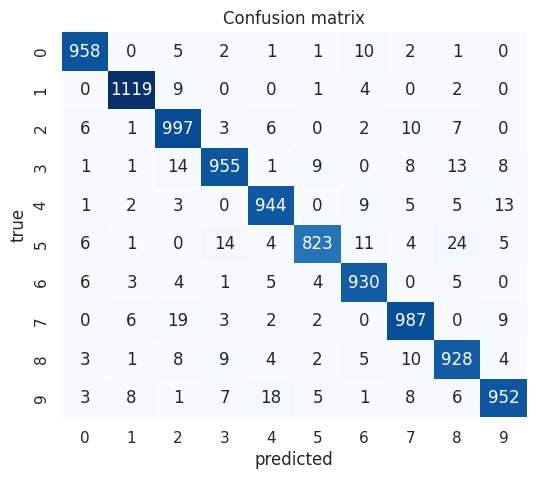

In [21]:
cm = confusion_matrix(y_test.numpy(), preds.numpy())
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("predicted"); plt.ylabel("true"); plt.title("Confusion matrix")
plt.show()

📌 **Overfitting & the role of Dropout**

A network with many parameters can **memorise** the training data instead of **learning** the
pattern — that is **overfitting**. You spot it when the **training loss keeps dropping** but the
**validation loss stops improving (or rises)**: a widening gap between the two curves.

### 🧠 Build the second architecture

In [22]:
class MnistMLPMish(nn.Module):
    def __init__(self, n_classes=10, p_drop=0.2):
        super().__init__()                       # required first line
        self.flatten = nn.Flatten()              # [B, 28, 28] -> [B, 784]
        self.fc1     = nn.Linear(28*28, 128)     # hidden layer 1
        self.fc2     = nn.Linear(128, 64)        # hidden layer 2
        self.fc3     = nn.Linear(64, 32)         # hidden layer 3
        self.out     = nn.Linear(32, n_classes) # 10 output neurons (logits)
        self.dropout = nn.Dropout(p_drop)

    def forward(self, x):
        x = self.flatten(x)
        x = F.mish(self.fc1(x))
        x = self.dropout(x)
        x = F.mish(self.fc2(x))
        x = self.dropout(x)
        x = F.mish(self.fc3(x))
        x = self.dropout(x)
        x = self.out(x)                          # raw logits, NO softmax here
        return x

model_02 = MnistMLPMish().to(device)
torchinfo.summary(model_02, input_size=(1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
MnistMLPMish                             [1, 10]                   --
├─Flatten: 1-1                           [1, 784]                  --
├─Linear: 1-2                            [1, 128]                  100,480
├─Dropout: 1-3                           [1, 128]                  --
├─Linear: 1-4                            [1, 64]                   8,256
├─Dropout: 1-5                           [1, 64]                   --
├─Linear: 1-6                            [1, 32]                   2,080
├─Dropout: 1-7                           [1, 32]                   --
├─Linear: 1-8                            [1, 10]                   330
Total params: 111,146
Trainable params: 111,146
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.11
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.44
Estimated Total Size (MB): 0.45

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_02.parameters(), lr=1e-3)

history = train_model(model_02, train_loader, val_loader, criterion, optimizer, n_epochs=15)

epoch   1/15  train_loss=1.1092  val_loss=0.4300
epoch   2/15  train_loss=0.4659  val_loss=0.3031
epoch   3/15  train_loss=0.3360  val_loss=0.2405
epoch   4/15  train_loss=0.2762  val_loss=0.2034
epoch   5/15  train_loss=0.2277  val_loss=0.1943
epoch   6/15  train_loss=0.1930  val_loss=0.1752
epoch   7/15  train_loss=0.1671  val_loss=0.1631
epoch   8/15  train_loss=0.1427  val_loss=0.1544
epoch   9/15  train_loss=0.1250  val_loss=0.1534
epoch  10/15  train_loss=0.1142  val_loss=0.1376
epoch  11/15  train_loss=0.0991  val_loss=0.1326
epoch  12/15  train_loss=0.0905  val_loss=0.1345
epoch  13/15  train_loss=0.0772  val_loss=0.1357
epoch  14/15  train_loss=0.0673  val_loss=0.1752
epoch  15/15  train_loss=0.0642  val_loss=0.1542


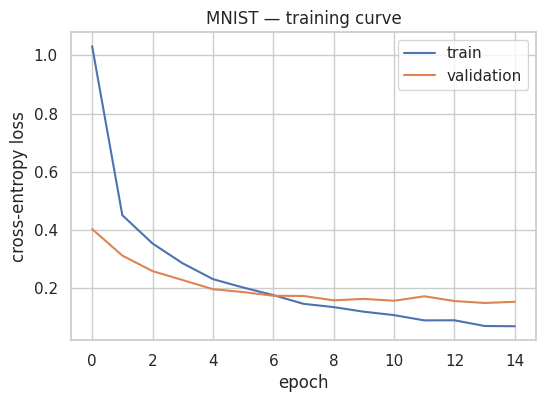

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"],   label="validation")
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("MNIST — training curve")
plt.legend()
plt.show()

In [24]:
model_02.eval()
with torch.no_grad():
    logits = model_02(X_test.to(device))
    probs  = torch.softmax(logits, dim=1)
    preds  = probs.argmax(dim=1).cpu()

In [25]:
nn_acc = accuracy_score(y_test.numpy(), preds.numpy())
print(f"Neural network test accuracy: {nn_acc:.3f}")

Neural network test accuracy: 0.952


# 📈 Part 2 — Regression: Auto MPG

Now the **same machinery**, but predicting a **number** instead of a class. The dataset describes
1970s–80s cars; we predict **`mpg`** (miles per gallon) from features like horsepower, weight,
and number of cylinders.

Watch how little changes: the training loop and `nn.Module` skeleton are the same — only the
**output layer**, **loss**, and **metric** differ (remember the table 🎯).

In [26]:
url = 'https://raw.githubusercontent.com/rasvob/VSB-FEI-Deep-Learning-Exercises/main/datasets/auto-mpg.csv'
df = pd.read_csv(url, na_values='?', sep=';')   # '?' marks missing values
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [27]:
# A few rows have a missing horsepower -> drop them (only a handful)
print("missing values before:\n", df.isna().sum()[df.isna().sum() > 0])
df = df.loc[~df.horsepower.isna(), :].copy()

missing values before:
 horsepower    6
dtype: int64


### 🏷️ Handling categorical features
`origin` is a **category** (1=USA, 2=Europe, 3=Japan), not a real number, so we **one-hot encode**
it. `car_name` has too many unique values to be useful here, so we drop it. 🚗

In [28]:
df = df.drop('car_name', axis=1)
df['origin'] = df['origin'].replace({1: 'USA', 2: 'EUR', 3: 'JAP'})
df = pd.get_dummies(df, columns=['origin'], prefix='origin', dtype=float)  # -> origin_USA / origin_EUR / origin_JAP
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_EUR,origin_JAP,origin_USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,0.0,0.0,1.0
1,15.0,8,350.0,165.0,3693.0,11.5,70,0.0,0.0,1.0
2,18.0,8,318.0,150.0,3436.0,11.0,70,0.0,0.0,1.0
3,16.0,8,304.0,150.0,3433.0,12.0,70,0.0,0.0,1.0
4,17.0,8,302.0,140.0,3449.0,10.5,70,0.0,0.0,1.0


In [29]:
X = df.drop('mpg', axis=1).values.astype('float32')   # features
y = df['mpg'].values.astype('float32')                # target (a real number)

# train / val / test split (60 / 20 / 20)
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.2, random_state=13)
X_train,  X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.25, random_state=13)
print("train:", X_train.shape, "| val:", X_val.shape, "| test:", X_test.shape)

train: (234, 9) | val: (79, 9) | test: (79, 9)


### 🔄 Why we must scale the features

Look at the raw features: `weight` is in the **thousands**, `model_year` is around **75**,
`cylinders` is **4–8**. These wildly different **magnitudes** make gradient descent unstable and
slow. We fix it with **`StandardScaler`** (mean 0, std 1) — fitted on the **training set only**,
then applied to val/test.

In [30]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [31]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1).to(device)

train_loader_r = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
val_loader_r   = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32)

### 📏 Baseline: Linear Regression
For regression the classic baseline is **linear regression**. If our network can't beat a straight
line, it isn't earning its keep.

In [38]:
lin = LinearRegression().fit(X_train, y_train)
lin_pred = lin.predict(X_test)
print(f"Linear Regression  ->  MAE: {mean_absolute_error(y_test, lin_pred):.2f} mpg | R2: {r2_score(y_test, lin_pred):.3f}")

Linear Regression  ->  MAE: 2.94 mpg | R2: 0.761


### 🧠 Build the regressor — spot the difference!

Compare this class with `MnistMLPFirst`. The **hidden part is the same idea** (Linear + ReLU +
Dropout). **Three things change**:

1. the **output layer** has **1 neuron** (we predict one number),
2. there is **no activation** on the output (a *linear* output can produce any real value),
3. we will use **`nn.MSELoss`** instead of `CrossEntropyLoss`.

In [32]:
class MpgMLP(nn.Module):
    def __init__(self, n_features, p_drop=0.1):
        super().__init__()
        self.fc1     = nn.Linear(n_features, 64)
        self.fc2     = nn.Linear(64, 32)
        self.out     = nn.Linear(32, 1)      # 1 output neuron
        self.dropout = nn.Dropout(p_drop)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.out(x)                      # NO activation -> real-valued output
        return x

model_reg = MpgMLP(n_features=X_train_tensor.shape[1]).to(device)
torchinfo.summary(model_reg, input_size=(1, X_train_tensor.shape[1]))

Layer (type:depth-idx)                   Output Shape              Param #
MpgMLP                                   [1, 1]                    --
├─Linear: 1-1                            [1, 64]                   640
├─Dropout: 1-2                           [1, 64]                   --
├─Linear: 1-3                            [1, 32]                   2,080
├─Linear: 1-4                            [1, 1]                    33
Total params: 2,753
Trainable params: 2,753
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

In [33]:
criterion = nn.MSELoss()                               # regression loss
optimizer = torch.optim.Adam(model_reg.parameters(), lr=1e-2)

history_reg = train_model(model_reg, train_loader_r, val_loader_r, criterion, optimizer, n_epochs=100)

epoch  10/100  train_loss=10.9279  val_loss=8.3209
epoch  20/100  train_loss=9.3086  val_loss=6.7227
epoch  30/100  train_loss=9.1575  val_loss=7.2707
epoch  40/100  train_loss=7.9490  val_loss=5.0727
epoch  50/100  train_loss=7.4390  val_loss=4.4678
epoch  60/100  train_loss=7.0773  val_loss=4.4092
epoch  70/100  train_loss=7.0598  val_loss=5.9562
epoch  80/100  train_loss=7.8048  val_loss=4.9930
epoch  90/100  train_loss=7.1650  val_loss=6.0157
epoch 100/100  train_loss=7.7533  val_loss=8.6802


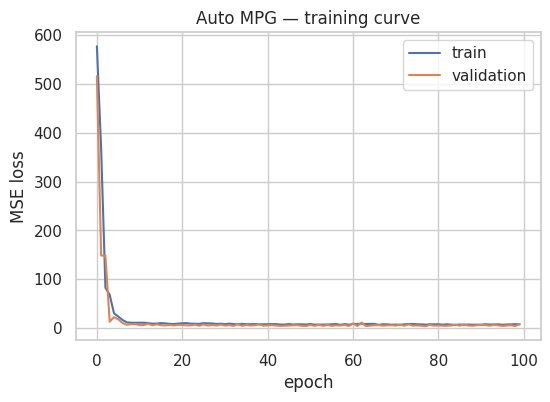

In [51]:
plt.figure(figsize=(6, 4))
plt.plot(history_reg["train_loss"], label="train")
plt.plot(history_reg["val_loss"],   label="validation")
plt.xlabel("epoch"); plt.ylabel("MSE loss"); plt.title("Auto MPG — training curve")
plt.legend(); plt.show()

### 📊 Regression metrics
There is no "accuracy" for numbers. Instead we measure **how far off** the predictions are:

- **MAE** — mean absolute error (average miss, in mpg) — easy to interpret.
- **RMSE** — root mean squared error — punishes big misses more.
- **$R^2$** — fraction of variance explained (1.0 = perfect, 0 = no better than predicting the mean).

In [50]:
model_reg.eval()
with torch.no_grad():
    y_pred = model_reg(X_test_tensor.to(device)).cpu().numpy().ravel()

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2   = r2_score(y_test, y_pred)
print(f"Neural network    ->  MAE: {mae:.2f} mpg | RMSE: {rmse:.2f} | R2: {r2:.3f}")
print(f"Linear Regression ->  MAE: {mean_absolute_error(y_test, lin_pred):.2f} mpg | R2: {r2_score(y_test, lin_pred):.3f}   <- baseline")

Neural network    ->  MAE: 2.44 mpg | RMSE: 3.32 | R2: 0.806
Linear Regression ->  MAE: 2.94 mpg | R2: 0.761   <- baseline


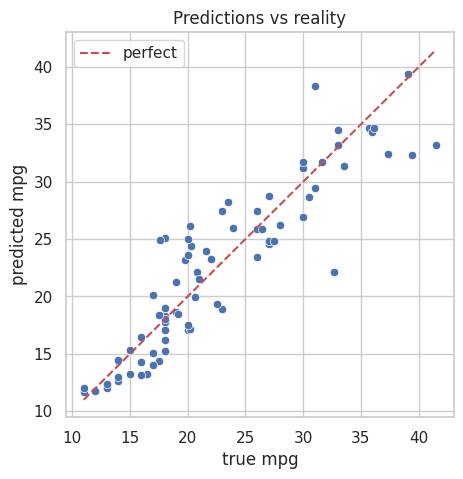

In [ ]:
# Predictions vs reality: perfect predictions would lie on the diagonal
plt.figure(figsize=(5, 5))
sns.scatterplot(x=y_test, y=y_pred)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', label="perfect")
plt.xlabel("true mpg"); plt.ylabel("predicted mpg"); plt.title("Predictions vs reality")
plt.legend(); plt.show()

# Activities ✏️

Now it's your turn. The cells below are **starting points** — read the hint, edit the code, re-run,
and observe. Aim to complete **at least three**.

## Activity 1 — Change the architecture 🏗️

Take **one** of the two networks — the **regressor**  *or* the **classifier** — and experiment with its architecture. Try changes below and compare the metric against the original.

1. **Hidden layer size** — make a layer wider or narrower.
2. **Number of layers** — add more hidden layers.
3. **Activation function** — replace `torch.relu` with another activation function.

For each variant, also look at the **model size** — the number of trainable parameters. Compare **size vs. metric**: does a bigger model actually predict better here, or just cost more parameters? 📊

epoch  10/100  train_loss=13.9599  val_loss=10.2609
epoch  20/100  train_loss=13.2697  val_loss=9.1282
epoch  30/100  train_loss=11.7171  val_loss=4.7869
epoch  40/100  train_loss=14.4535  val_loss=4.9126
epoch  50/100  train_loss=13.0313  val_loss=4.8442
epoch  60/100  train_loss=11.1472  val_loss=4.2425
epoch  70/100  train_loss=13.2034  val_loss=4.4432
epoch  80/100  train_loss=10.3001  val_loss=9.7900
epoch  90/100  train_loss=10.9616  val_loss=4.1599
epoch 100/100  train_loss=9.6023  val_loss=4.8233


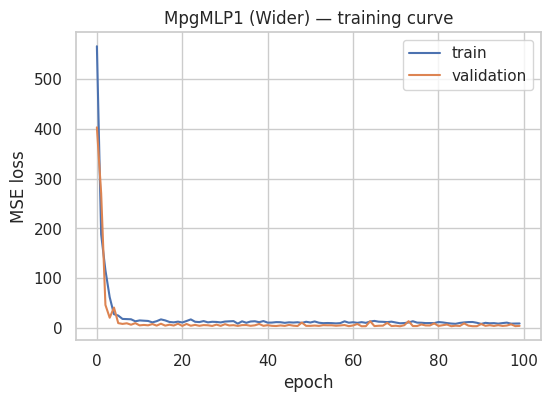

Model 1 mae: 2.59 mpg  | R2: 0.796


In [56]:
class mpgmlp1(nn.Module):
    def __init__(self, n_features, p_drop=0.1):
        super().__init__()
        self.fc1     = nn.Linear(n_features, 256)
        self.fc2     = nn.Linear(256, 128)
        self.out     = nn.Linear(128, 1)
        self.dropout = nn.Dropout(p_drop)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.out(x)
        return x

class mpgmlp2(nn.Module):
    def __init__(self, n_features, p_drop=0.1):
        super().__init__()
        self.fc1     = nn.Linear(n_features, 64)
        self.fc2     = nn.Linear(64, 32)
        self.fc3     = nn.Linear(32, 16)
        self.out     = nn.Linear(16, 1)
        self.dropout = nn.Dropout(p_drop)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        x = torch.relu(self.fc3(x))
        x = self.out(x)
        return x

class mpgmlp3(nn.Module):
    def __init__(self, n_features, p_drop=0.1):
        super().__init__()
        self.fc1     = nn.Linear(n_features, 64)
        self.fc2     = nn.Linear(64, 32)
        self.out     = nn.Linear(32, 1)
        self.dropout = nn.Dropout(p_drop)

    def forward(self, x):
        x = F.gelu(self.fc1(x))
        x = self.dropout(x)
        x = F.gelu(self.fc2(x))
        x = self.out(x)
        return x


model_v1 = mpgmlp2(n_features=X_train_tensor.shape[1]).to(device)
# torchinfo.summary(model_v1, input_size=(1, X_train_tensor.shape[1]))

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_v1.parameters(), lr=1e-2)

history_v1 = train_model(model_v1, train_loader_r, val_loader_r, criterion, optimizer, n_epochs=100)

plt.figure(figsize=(6, 4))
plt.plot(history_v1["train_loss"], label="train")
plt.plot(history_v1["val_loss"],   label="validation")
plt.xlabel("epoch"); plt.ylabel("MSE loss"); plt.title("MpgMLP1 (Wider) — training curve")
plt.legend(); plt.show()

model_v1.eval()
with torch.no_grad():
    y_pred = model_v1(X_test_tensor.to(device)).cpu().numpy().ravel()

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2   = r2_score(y_test, y_pred)
print(f"Model 1 mae: {mae:.2f} mpg  | R2: {r2:.3f}")


# mpgmlp1 w: R2 0.808
# mpgmlp2 d: R2 0.822
# mpgmlp3 g: R2 0.794

## Activity 2 — Tune the Dropout rate 🎛️

Take **one** of the two networks — the **classifier** or the **regressor**  — and try `p_drop` values of `0.0`, `0.5`, `0.8`. Rebuild and retrain the model for each value, then plot the **train vs. validation** loss curves.

Which value keeps the train and validation curves **closest together**? What happens when dropout is **too high**?


--- Trénuji s p_drop = 0.0 ---
epoch  10/100  train_loss=7.6013  val_loss=6.6161
epoch  20/100  train_loss=6.2572  val_loss=6.0073
epoch  30/100  train_loss=5.9177  val_loss=5.9214
epoch  40/100  train_loss=5.8183  val_loss=4.9491
epoch  50/100  train_loss=5.3349  val_loss=5.6937
epoch  60/100  train_loss=5.7940  val_loss=5.9691
epoch  70/100  train_loss=5.2760  val_loss=5.8150
epoch  80/100  train_loss=6.0752  val_loss=6.8349
epoch  90/100  train_loss=5.3411  val_loss=6.3923
epoch 100/100  train_loss=4.7848  val_loss=8.7524


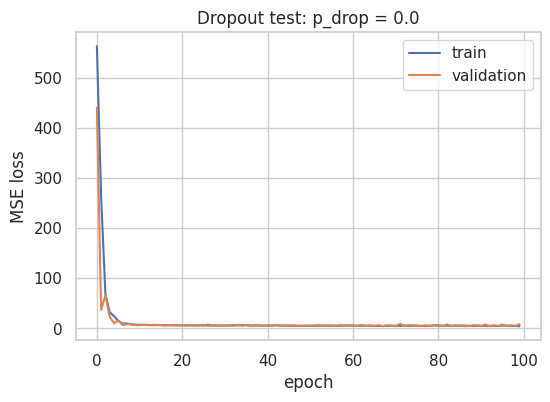


--- Trénuji s p_drop = 0.5 ---
epoch  10/100  train_loss=29.1606  val_loss=6.3005
epoch  20/100  train_loss=22.9506  val_loss=5.4389
epoch  30/100  train_loss=21.3408  val_loss=6.4183
epoch  40/100  train_loss=18.7967  val_loss=4.8882
epoch  50/100  train_loss=19.0491  val_loss=4.0928
epoch  60/100  train_loss=16.0732  val_loss=4.0458
epoch  70/100  train_loss=14.6866  val_loss=4.8512
epoch  80/100  train_loss=14.1486  val_loss=8.0646
epoch  90/100  train_loss=10.6441  val_loss=5.2978
epoch 100/100  train_loss=13.7355  val_loss=6.9919


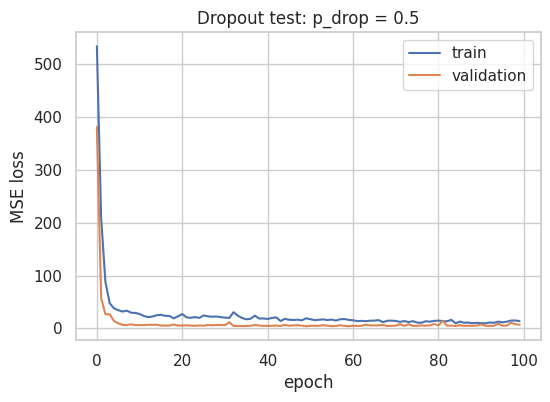


--- Trénuji s p_drop = 0.8 ---
epoch  10/100  train_loss=66.9082  val_loss=9.0804
epoch  20/100  train_loss=49.2192  val_loss=11.7379
epoch  30/100  train_loss=35.2090  val_loss=15.9735
epoch  40/100  train_loss=22.1953  val_loss=21.2585
epoch  50/100  train_loss=18.9238  val_loss=15.3631
epoch  60/100  train_loss=17.1955  val_loss=8.7679
epoch  70/100  train_loss=20.7492  val_loss=12.2773
epoch  80/100  train_loss=19.9107  val_loss=11.0159
epoch  90/100  train_loss=18.4693  val_loss=6.2962
epoch 100/100  train_loss=14.4213  val_loss=11.3690


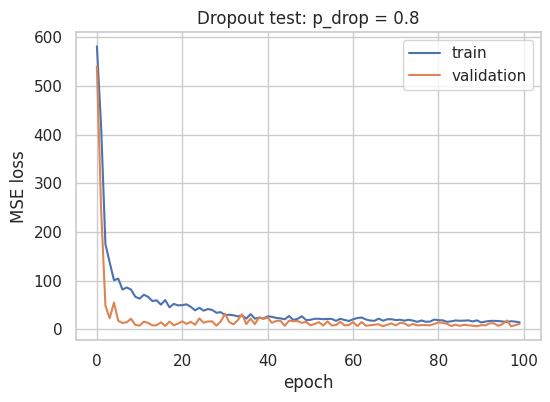

In [55]:
class dptest1(nn.Module):
    def __init__(self, n_features, p_drop=0.1):
        super().__init__()
        self.fc1     = nn.Linear(n_features, 64)
        self.fc2     = nn.Linear(64, 32)
        self.out     = nn.Linear(32, 1)
        self.dropout = nn.Dropout(p_drop)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.out(x)
        return x


dropout_values = [0.0, 0.5, 0.8]

for p in dropout_values:
    print(f"\n--- Trénuji s p_drop = {p} ---")
    model_drop = dptest1(n_features=X_train_tensor.shape[1], p_drop=p).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model_drop.parameters(), lr=1e-2)

    history = train_model(model_drop, train_loader_r, val_loader_r, criterion, optimizer, n_epochs=100)

    plt.figure(figsize=(6, 4))
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"],   label="validation")
    plt.xlabel("epoch")
    plt.ylabel("MSE loss")
    plt.title(f"Dropout test: p_drop = {p}")
    plt.legend()
    plt.show()

## Activity 3 — Break it on purpose: the output-activation trap ☣️
Scale the target `mpg` into `(0, 1)` and add a **`sigmoid`** to the output of the regressor.
Train it — the predictions will be badly capped. Then **remove the sigmoid** (linear output) and
watch it recover. This shows why the output activation must match your target range.

## Activity 4 — Transform the target with PowerTransformer 🎯

Try to use `PowerTransformer` for the output values in a similar manner as the `MinMaxScaler`.

- When do we use it? Why?
- If you wanted to guess if it helps, what do you think?
    - Plot a histogram of the output (`mpg`), you can make an educated guess based on it 😋

> 💡 Retrain `MpgMLP`, then
> `inverse_transform` the predictions back before scoring. Keep the output **linear**.